In [ ]:
!pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.2 MB/s eta 0:00:00


Trial 5 Complete [00h 01m 02s]
val_loss: 0.07710617780685425

Best val_loss So Far: 0.07191270589828491
Total elapsed time: 00h 05m 22s
✅ Best number of filters: 48
✅ Best learning rate: 0.001
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.1340 - val_loss: 0.0853
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0828 - val_loss: 0.0796
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0789 - val_loss: 0.0770
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0770 - val_loss: 0.0757
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0760 - val_loss: 0.0750
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0753 - val_loss: 0.0743
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0747 - val_loss: 0.0742
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0743 - val_loss: 0.0735
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0739 - val_loss: 0.0731
Epoch 10/15
469/469 ━━━━━━━━━━━

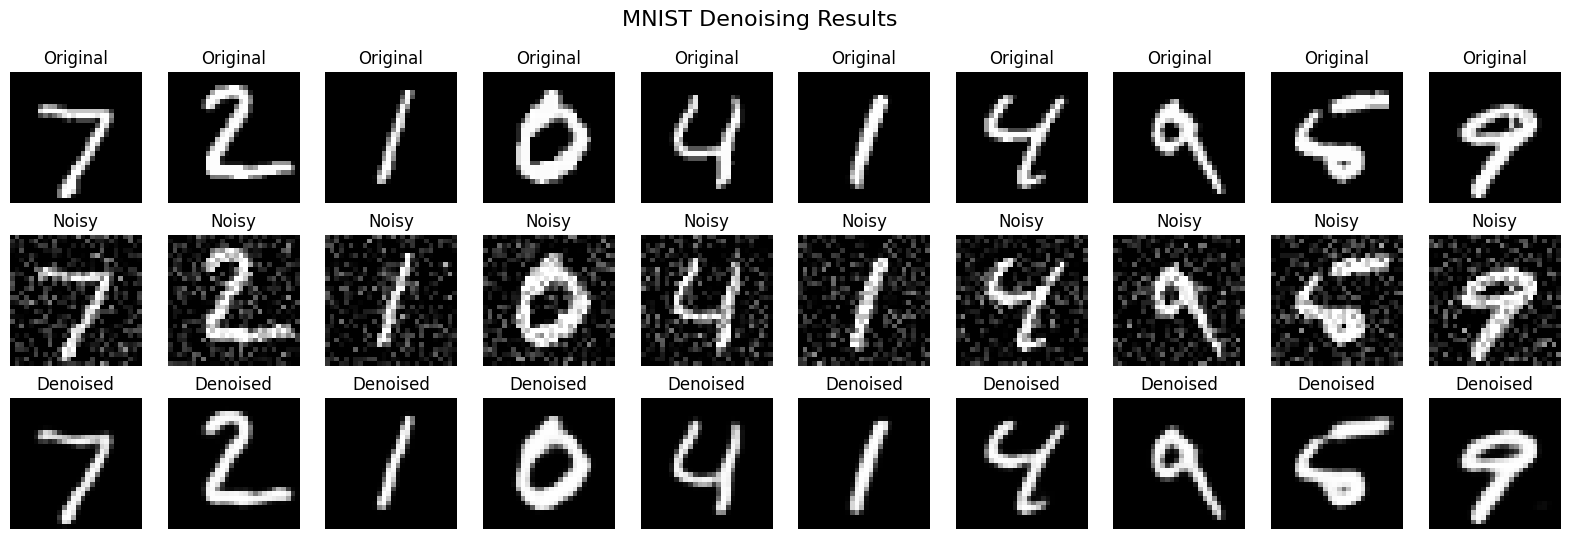

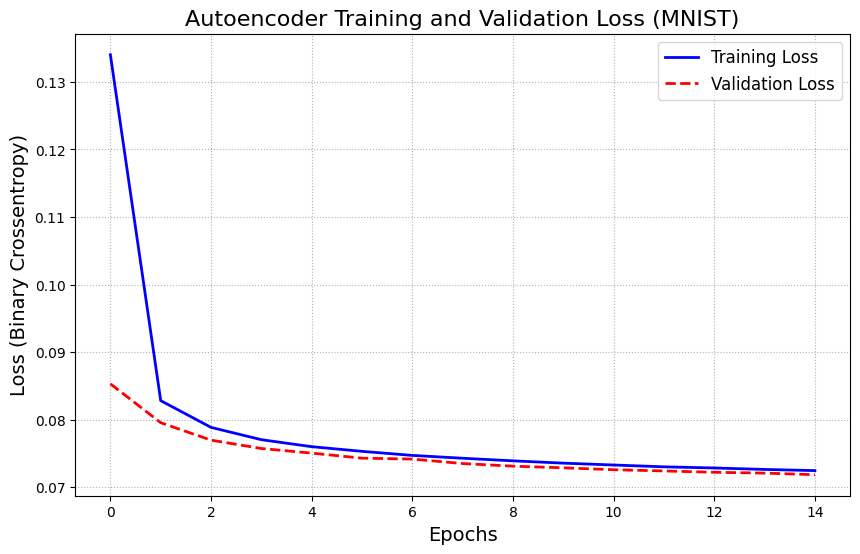

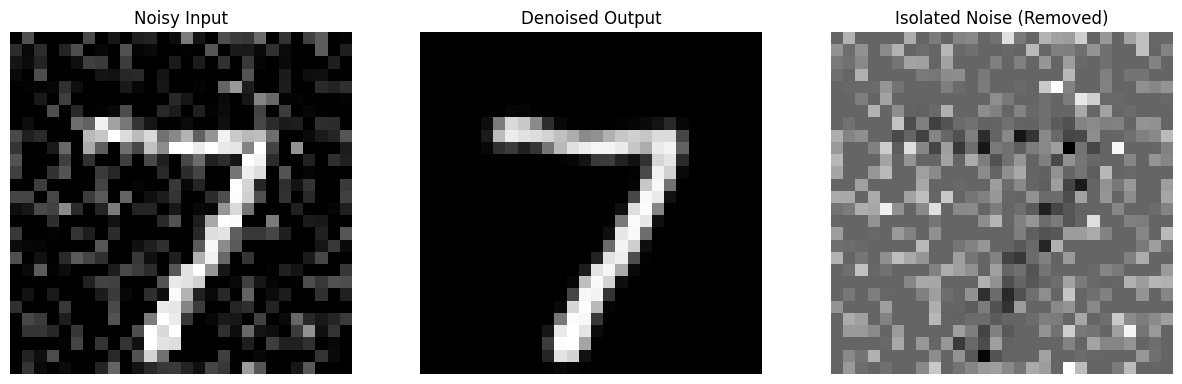

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
from IPython.display import Image

# ==================== 1. LOAD MNIST DATASET ====================
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32')  / 255.

x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test,  axis=-1)

# ==================== 2. ADD GAUSSIAN NOISE ====================
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy  = x_test  + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, 0., 1.)
x_test_noisy  = tf.clip_by_value(x_test_noisy,  0., 1.)

# ==================== 3. BUILD MODEL WITH TUNABLE HP ====================
def build_model(hp):
    inputs = layers.Input(shape=(28, 28, 1))
    hp_filters = hp.Int('filters', min_value=16, max_value=64, step=16)

    # Encoder
    x = layers.Conv2D(hp_filters, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(hp_filters // 2, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(hp_filters // 2, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(hp_filters, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, decoded)

    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr),
                  loss='binary_crossentropy')
    return model

# ==================== 4. HYPERPARAMETER TUNING (Random Search) ====================
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='autoencoder_tuning_mnist',
    project_name='denoising_mnist'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

tuner.search(x_train_noisy, x_train,
             epochs=10,
             validation_split=0.2,
             callbacks=[stop_early],
             verbose=1)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("✅ Best number of filters:", best_hps.get('filters'))
print("✅ Best learning rate:", best_hps.get('learning_rate'))

# ==================== 5. FINAL TRAINING WITH BEST HP ====================
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(x_train_noisy, x_train,
                         epochs=15,
                         batch_size=128,
                         shuffle=True,
                         validation_data=(x_test_noisy, x_test),
                         verbose=1)

# ==================== 6. PREDICTION & VISUALIZATIONS (exactly like PDF) ====================
decoded_imgs = best_model.predict(x_test_noisy)

# Plot 1: Original | Noisy | Denoised (10 examples)
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(tf.squeeze(x_test[i]), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(tf.squeeze(x_test_noisy[i]), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(tf.squeeze(decoded_imgs[i]), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")
plt.suptitle("MNIST Denoising Results", fontsize=16)
plt.show()

# Plot 2: Training vs Validation Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
plt.title('Autoencoder Training and Validation Loss (MNIST)', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss (Binary Crossentropy)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':')
plt.show()

# Plot 3: Model Architecture
plot_model(best_model, to_file='autoencoder_architecture_mnist.png',
           show_shapes=True, show_layer_names=True, dpi=100)
Image('autoencoder_architecture_mnist.png')

# Plot 4: Isolated Noise (Removed Noise)
index = 0
isolated_noise = x_test_noisy[index] - decoded_imgs[index]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(tf.squeeze(x_test_noisy[index]), cmap='gray')
plt.title("Noisy Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(tf.squeeze(decoded_imgs[index]), cmap='gray')
plt.title("Denoised Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(tf.squeeze(isolated_noise), cmap='gray')
plt.title("Isolated Noise (Removed)")
plt.axis("off")
plt.show()